In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
tab_sdpt_fp = pd.read_csv("/share/homes/boyerma/FastSDPCertification/results/benchmark/9x100-0.026/2026_06_05_16h20_51s_test-jz-SDPt-RLT=10-FP/results_all.csv")
tab_sdpt_fp = tab_sdpt_fp.sort_values(
    by=["data_index", "target"]
)
tab_sdpt_fp = tab_sdpt_fp.reset_index(drop= True)

In [3]:
tab_sdpt_pp = pd.read_csv("/share/homes/boyerma/FastSDPCertification/results/benchmark/9x100-0.026/2026_06_12_19h27_06s_SDPt-RLT=10/results_all.csv")
tab_sdpt_pp = tab_sdpt_pp.sort_values(
    by=["data_index", "target"]
)
tab_sdpt_pp = tab_sdpt_pp.reset_index(drop = True)

In [4]:
meme_ordre = (
    tab_sdpt_fp[["data_index", "target"]]
    .equals(tab_sdpt_pp[["data_index", "target"]])
)
meme_ordre


True

In [5]:
columns_per_model = ['Nb_constraints', 'Nb_variables', 'time', 'optimal_value']
cols = ['data_index', 'target']
for col in columns_per_model:
    cols.append(f'PP_{col}')
    cols.append(f'FP_{col}')

In [6]:
for data_index in range(100):
    for target in range(10):
        nb_fp = ((tab_sdpt_fp["data_index"] == data_index) & (tab_sdpt_fp["target"] == target)).sum()
        if nb_fp > 1:
            print(f"Erreur sur data_index={data_index}, target = {target} : nb_fp = {nb_fp}")

In [7]:
tab_sdpt_fp['Nb_variables'].value_counts()

Series([], Name: count, dtype: int64)

In [8]:
tab_sdpt_fp[tab_sdpt_fp['data_index']==13][columns_per_model].head(20)

,Nb_constraints,Nb_variables,time,optimal_value
117,28881,NaN,263.544151,-1550.162984
118,28881,NaN,253.642304,-1388.554147
119,28881,NaN,289.991887,-1437.700233
120,28881,NaN,245.519022,-1505.128010
121,28881,NaN,250.857539,-1405.043433
122,28881,NaN,280.586504,-1494.528072
123,28881,NaN,273.215841,-1397.943474
124,28881,NaN,257.399701,-1396.654521
125,28881,NaN,260.645352,-1581.554081


In [9]:
for data_index in range(100):
    for target in range(10):
        nb_pp = ((tab_sdpt_pp["data_index"] == data_index) & (tab_sdpt_pp["target"] == target)).sum()
        nb_fp = ((tab_sdpt_fp["data_index"] == data_index) & (tab_sdpt_fp["target"] == target)).sum()
        if nb_pp != nb_fp :
            print(f"Différence sur data_index={data_index}, target = {target} : nb_pp = {nb_pp}, nb_fp = {nb_fp}")

In [14]:
tab_diff = pd.DataFrame()
tab_diff['data_index'] = tab_sdpt_fp['data_index']
tab_diff['target'] = tab_sdpt_fp['target']
tab_diff[['Nb_stable_inactives', 'Nb_stable_actives']] = tab_sdpt_fp[['Nb_stable_inactives', 'Nb_stable_actives']].copy()
tab_diff['Nb_unstable'] = 900 - (tab_diff['Nb_stable_actives'] + tab_diff['Nb_stable_inactives'])
tab_diff["Stable_active/Unstable"] = tab_diff['Nb_stable_actives']/tab_diff['Nb_unstable']
tab_diff["Stable_active/Inactive"] = tab_diff['Nb_stable_actives']/tab_diff['Nb_stable_inactives']
for criterium in columns_per_model :
    tab_diff[f"diff_{criterium}"] = tab_sdpt_fp[criterium] - tab_sdpt_pp[criterium]
tab_diff["diff_time_prop"] = (tab_sdpt_fp['time'] - tab_sdpt_pp['time']) / tab_sdpt_pp['time']
tab_diff['diff_gap_abs'] = (tab_sdpt_fp['optimal_value'] - tab_sdpt_pp['optimal_value']) / tab_sdpt_pp['optimal_value']

In [15]:
tab_diff

,data_index,target,Nb_stable_inactives,Nb_stable_actives,Nb_unstable,Stable_active/Unstable,Stable_active/Inactive,diff_Nb_constraints,diff_Nb_variables,diff_time,diff_optimal_value,diff_time_prop,diff_gap_abs
0,0,1,478,287,135,2.125926,0.600418,-16134,NaN,-191.214601,-0.000036,-0.788888,-0.000005
1,0,2,478,287,135,2.125926,0.600418,-16134,NaN,-195.861386,-0.000061,-0.793946,-0.000016
2,0,3,478,287,135,2.125926,0.600418,-16134,NaN,-188.784664,-0.000022,-0.794232,-0.000003
3,0,4,478,287,135,2.125926,0.600418,-16134,NaN,-152.106791,-0.000022,-0.774570,-0.000002
4,0,5,478,287,135,2.125926,0.600418,-16134,NaN,-163.158257,-0.000042,-0.778771,-0.000008
...,...,...,...,...,...,...,...,...,...,...,...,...,...
858,99,4,464,295,141,2.092199,0.635776,-16358,NaN,-220.651141,-0.000066,-0.907221,-0.000026
859,99,5,464,295,141,2.092199,0.635776,-16358,NaN,-246.339796,-0.000095,-0.906361,0.000045
860,99,6,464,295,141,2.092199,0.635776,-16358,NaN,-217.316127,-0.000033,-0.899044,-0.001437
861,99,7,464,295,141,2.092199,0.635776,-16358,NaN,-183.034417,-0.000033,-0.873989,-0.000079


In [16]:
abscisse = 'Stable_active/Unstable'
criteria = ['time', 'time_prop', 'optimal_value', 'Nb_constraints', 'gap_abs']


quantiles = 15

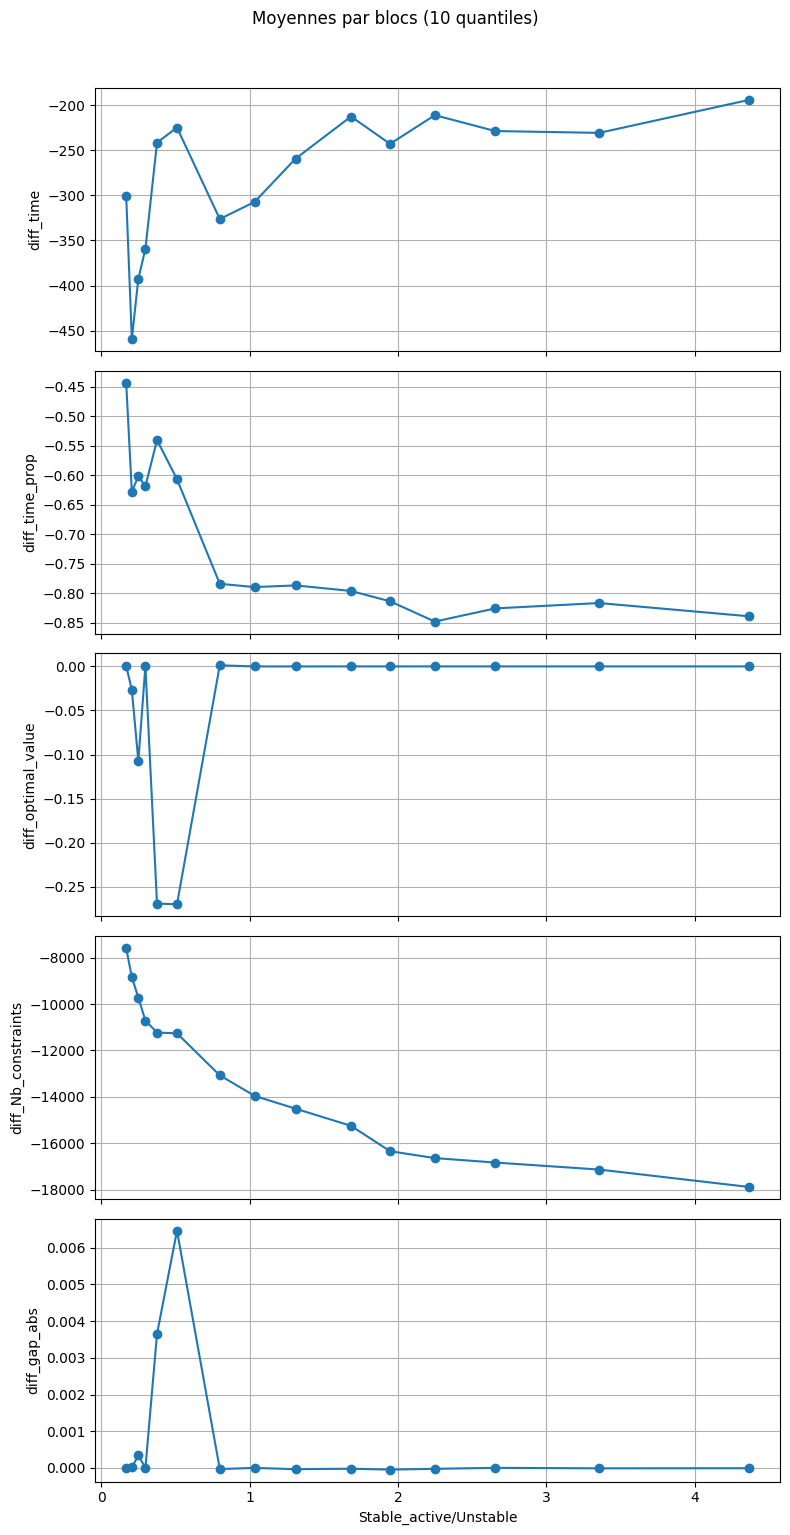

In [17]:
for i in range(len(criteria)):
    criteria[i] = f'diff_{criteria[i]}'


df = tab_diff[[abscisse] +criteria].dropna().copy()

# 10 blocs
df["bin"] = pd.qcut(df[abscisse], q=quantiles, labels=False, duplicates="drop")

# Moyennes par bloc
df_plot = df.groupby("bin").mean().reset_index(drop=True)

n = len(criteria)
fig, axes = plt.subplots(n, 1, figsize=(8, 3*n), sharex=True)

if n == 1:
    axes = [axes]

for ax, crit in zip(axes, criteria):
    ax.plot(df_plot[abscisse], df_plot[crit], marker="o")
    ax.set_ylabel(crit)
    ax.grid(True)

axes[-1].set_xlabel(abscisse)
fig.suptitle("Moyennes par blocs (10 quantiles)", y=1.02)

plt.tight_layout()
plt.show()